<a href="https://colab.research.google.com/github/Shubham-Sahoo/acceleration-flow-matching/blob/colab/notebooks/ddpm_latent_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
!git clone https://github.com/shubham-sahoo/acceleration-flow-matching.git
os.chdir('acceleration-flow-matching')

Cloning into 'acceleration-flow-matching'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 49 (delta 16), reused 36 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 162.39 KiB | 1.32 MiB/s, done.
Resolving deltas: 100% (16/16), done.


In [2]:
import sys
sys.path.append("/content/acceleration-flow-matching/src")


In [3]:
import torch
import torch.nn as nn
from torch.optim import Adam
from models import LatentViT
from data_loader import train_loader
from vae import SpatialVae
from tqdm import tqdm
from diffusion import DDPMSpatialLatent
from utils import visualize_samples


torch.Size([8, 16, 8, 8])
Model parameters: 5.39M
✓ Model ready


100%|██████████| 170M/170M [00:04<00:00, 41.7MB/s]


50000


In [4]:
def train_ddpm(model_sampler: DDPMSpatialLatent, train_loader, device='cpu', epochs=5, lr=1e-4):
    optimizer = Adam(model_sampler.model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    num_steps = 1000
    betas = torch.linspace(0.0001, 0.02, num_steps, device=device)
    alphas = 1 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    sqrt_alpha_bars = torch.sqrt(alpha_bars)
    sqrt_1_minus_alpha_bars = torch.sqrt(1 - alpha_bars)

    model_sampler.model.train()

    for epoch in range(epochs):
        total_loss = 0
        progress_bar = tqdm(train_loader, desc=f"DDPM Epoch {epoch+1}/{epochs}")

        for batch_idx, (x, _) in enumerate(progress_bar):

            loss = model_sampler.forward_loss(x, num_steps, criterion)

            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model_sampler.model.parameters(), 1.0)

            optimizer.step()

            total_loss += loss.item()
            progress_bar.set_postfix({'loss': loss.item()})

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1} - DDPM Loss: {avg_loss:.6f}\n")

    return model_sampler.model

In [14]:
device = 'cuda'
model = LatentViT(latent_channels=16, embed_dim=192, depth=12, num_heads=3)
model = model.to(device)

vae = SpatialVae()
vae.load_state_dict(torch.load('spatial_vae.pth', map_location=torch.device('cuda'), weights_only=True))

vae = vae.to(device)

model_ddpm = DDPMSpatialLatent(model, vae=vae, device=device)


In [18]:

model = train_ddpm(model_ddpm, train_loader, device=device, epochs=20, lr=1e-4)

DDPM Epoch 1/20: 100%|██████████| 782/782 [01:14<00:00, 10.52it/s, loss=0.385]


Epoch 1 - DDPM Loss: 0.282128



DDPM Epoch 2/20: 100%|██████████| 782/782 [01:13<00:00, 10.62it/s, loss=0.346]


Epoch 2 - DDPM Loss: 0.279405



DDPM Epoch 3/20: 100%|██████████| 782/782 [01:13<00:00, 10.61it/s, loss=0.31]


...

Epoch 18 - DDPM Loss: 0.273844



DDPM Epoch 19/20: 100%|██████████| 782/782 [01:13<00:00, 10.67it/s, loss=0.29]


Epoch 19 - DDPM Loss: 0.272402



DDPM Epoch 20/20: 100%|██████████| 782/782 [01:13<00:00, 10.66it/s, loss=0.24]

Epoch 20 - DDPM Loss: 0.271941



In [19]:
torch.save(model.state_dict(), 'ddpm_latent_model.pth')
print("✓ Model saved to ddpm_latent_model.pth")

✓ Model saved to ddpm_latent_model.pth


DDPM: 100%|██████████| 500/500 [00:04<00:00, 118.62it/s]


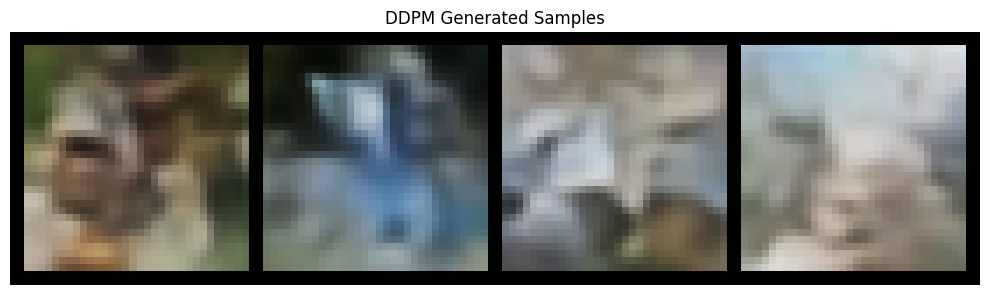

In [24]:
sampler = model_ddpm


# Cell 4: Test and Benchmark

# Generate samples
z_noise = torch.randn(4, 16, 8, 8, device=device)
x_samples = sampler.sample(z_noise, t_steps=500, verbose=True)


# Benchmark
# result = benchmark(sampler, batch_size=4, t_steps=50, num_runs=2)
# print(f"\nDDPM 50 steps: {result['mean_time_s']:.2f}s ± {result['std_time_s']:.2f}s")

# # Visualize
visualize_samples(x_samples, title="DDPM Generated Samples")

In [40]:
import matplotlib.pyplot as plt
def visualize_reconstruction(vae, sampler, test_loader, device='cuda', num_samples=16):
    """Side-by-side original and reconstructed images"""
    # vae.eval()

    x_test, _ = next(iter(test_loader))
    x_test = x_test[:num_samples].to(device)

    with torch.no_grad():
        z_noise = vae.encode_only(x_test)

        x_recon = sampler.sample(z_noise, t_steps=500, verbose=True)

    x_test_viz = (x_test.cpu() + 1) / 2
    x_recon_viz = (x_recon.cpu() + 1) / 2

    fig, axes = plt.subplots(2, num_samples // 2, figsize=(16, 6))
    fig.suptitle('VAE Reconstruction Comparison', fontsize=16)

    idx = 0
    for i in range(1):
        for j in range(num_samples // 2):
            axes[i, j].imshow(x_test_viz[idx].permute(1, 2, 0).numpy())
            axes[i, j].set_title(f"{'Original'} {idx}")
            axes[i, j].axis('off')
            idx += 1

        idx = 0
        for j in range(num_samples // 2):
            axes[i+1, j].imshow(x_recon_viz[idx].permute(1, 2, 0).numpy())
            axes[i+1, j].set_title(f"{'Reconstructed'} {idx}")
            axes[i+1, j].axis('off')
            idx += 1

    plt.tight_layout()
    plt.show()

In [41]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
test_dataset = datasets.CIFAR10(root='./data', train=False, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)


DDPM: 100%|██████████| 500/500 [00:04<00:00, 118.32it/s]


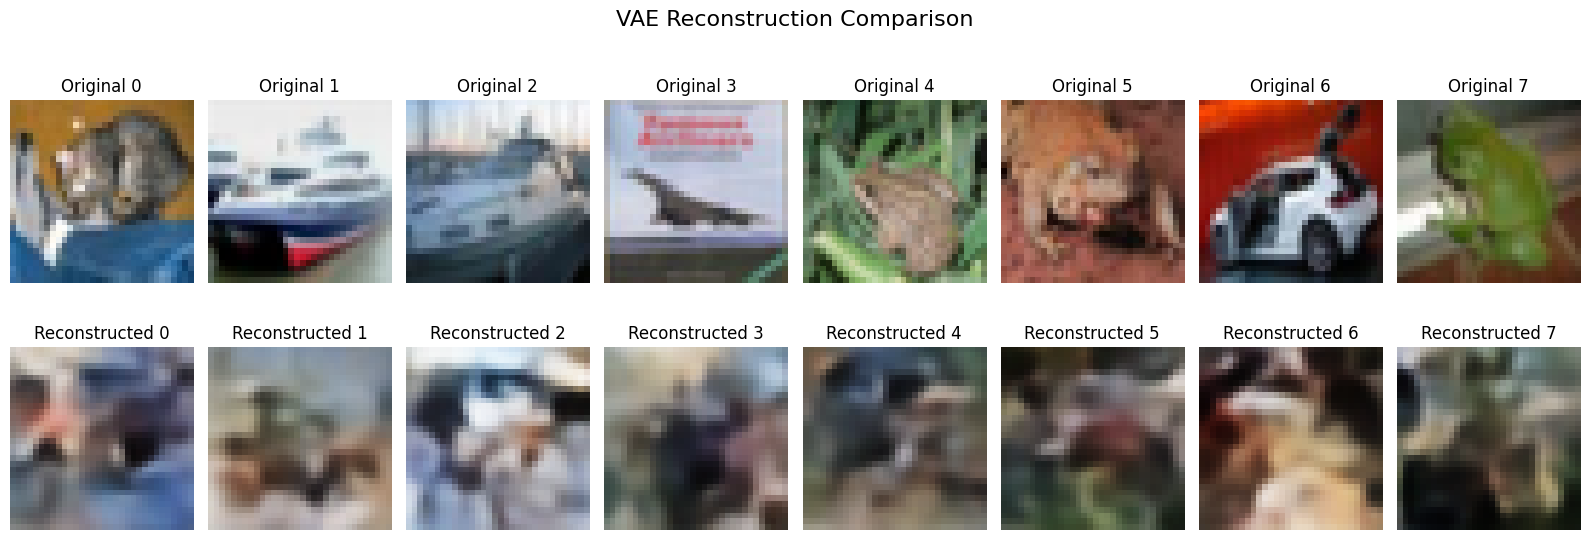

In [42]:
sampler.model = sampler.model.to(device=device)
visualize_reconstruction(vae.to(device=device), sampler, test_loader)